# IrriGator — Full End-to-End Pipeline

Central notebook covering **every block** from raw data to irrigation recommendation.

| Block | What | Data source | Run frequency |
|-------|------|-------------|---------------|
| 0 | Data ingestion | ERA5-Land (France-wide), COMEPHORE, Sentinel-2, soil, DEM | Once (historical archive) |
| 1 | Static layers | EU-SoilHydroGrids, IGN DEM | Once per parcel |
| 2 | Atmospheric forcing | ERA5-Land daily → parcel extraction | Once (cache), then per parcel |
| 3+4 | Simulation | Water balance + crop growth ACQUACROP | Daily |
| 5a | Short-term forecast | AROME (0-48h) + IFS ENS (0-15d) → ensemble | Daily |
| 5b | Seasonal outlook | SEAS5 → PCA analog → ensemble water balance | Monthly |
| 6 | Decision | Ensemble stress → irrigation recommendation | Daily |

**Architecture change:** ERA5-Land is now downloaded once for all of metropolitan
France (41°N–51.5°N, 6°W–10°E). Any new parcel is served from this cache
without additional API calls. AROME and IFS ENS already work the same way.

---
## Configuration — set your "today" and paths here

In [ ]:
import logging
import os
from datetime import date
from pathlib import Path
from datetime import timedelta

# === EDIT THESE ===
REPO_ROOT = os.path.dirname(os.getcwd())  # adjust if needed
os.chdir(REPO_ROOT)

TODAY = date(2025, 12, 31)          # the date we treat as "today"
# TODAY = date.today()
SIMULATION_START = date(2025, 1, 1) # start of the growing season simulation
LAST_IRRIGATION = None              # date of last irrigation, or None for rainfed
RUN_SEAS5 = False                   # set True to include seasonal outlook (monthly run)
PLOT_SEAS5_PCA = True  # diagnostic ERA5-vs-SEAS5 PC1/PC2 figure
FETCH_SEAS5_HINDCASTS = False  # one-time: fetch 1993-2016 hindcasts for current init month
REFRESH_SEAS5 = False  # set True once if an old 2-variable SEAS5 cache exists
RUN_YIELD_OPTIMIZER = False  # requires RUN_SEAS5=True for a harvest-horizon objective
RUN_BRANCH_EQUIVALENCE_TEST = False  # compare private branching vs full AquaCrop on 3 members
RUN_HISTORICAL_OPTIMIZER = False  # retrospective fixed-date dose optimization

SHIFT = 0                           # set to 1 if you want UTC+1

# Paths — all relative to REPO_ROOT
RAW_DIR = Path("data/raw")                # ERA5-Land, SEAS5, IFS ENS raw downloads
PROCESSED_DIR = Path("data/processed")     # daily aggregates, cached results
STATIC_DIR = Path("data/static")           # static ERA5-Land data (soil, land cover, etc.)


# Parcel and region configs (region still needed for static layers)
REGION_CONFIG = "configs/dordogne.yaml"
PARCEL_CONFIG = f"configs/parcels/billac_{TODAY.year}.yaml"
PARCEL_CONFIG2 = f"configs/parcels/billac_{TODAY.year}_test_irr.yaml"
HISTORICAL_PARCEL_CONFIG = f"configs/parcels/billac_{TODAY.year}.yaml"

CROP_PARAMS_PATH = "configs/crop_parameters.yaml"
MODEL_PARAMS_PATH = "configs/model_parameters.yaml"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(name)s] %(levelname)s: %(message)s",
    datefmt="%H:%M:%S",
)

print(f"Repo root: {REPO_ROOT}")
print(f"Today:     {TODAY}")
print(f"Raw dir:   {RAW_DIR}")
print(f"Processed: {PROCESSED_DIR}")

Repo root: /home/mbaldacchino/code/IrriGator
Today:     2025-12-31
Raw dir:   data/raw
Processed: data/processed


---
## Block 0 — Data Ingestion

Run these cells **once** to download and cache the historical archive.
Skip if data is already on disk.

ERA5-Land is downloaded for all of France — not per region. One download
covers any parcel in metropolitan France.

In [2]:
from irrigator.config import load_region_config, load_parcel_config

cfg = load_region_config(REGION_CONFIG)
parcel = load_parcel_config(PARCEL_CONFIG)
parcel2 = load_parcel_config(PARCEL_CONFIG2)

print(f"Region: {cfg.name} (dept {cfg.code_departement})")
print(f"Parcel: {parcel.name} ({parcel.id})")
print(f"Crop:   {parcel.crop.get('type')} — planting {parcel.crop.get('planting_date')}")

Region: Dordogne (dept 24)
Parcel: Parcelle Billac - SEP des Pouyades (billac_001)
Crop:   grain_maize — planting 2025-04-14


In [5]:
# --- ERA5-Land download (skip if already done) ---
# France-wide, no per-region dependency
from irrigator.ingestion.cds_client import fetch_era5_land_range
fetch_era5_land_range(date(2025, 12, 1), date.today(), raw_dir=RAW_DIR, overwrite=True, force_cds_refresh=False)

12:59:32 [irrigator.ingestion.cds_client] INFO: Requesting ERA5-Land 2025-12 from CDS...


['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31']


2026-08-18 12:59:33,380 INFO Request ID is 129a6228-dd65-4d79-b244-89ee1f995775
12:59:33 [ecmwf.datastores.legacy_client] INFO: Request ID is 129a6228-dd65-4d79-b244-89ee1f995775
2026-08-18 12:59:33,435 INFO status has been updated to accepted
12:59:33 [ecmwf.datastores.legacy_client] INFO: status has been updated to accepted


KeyboardInterrupt: 

In [ ]:
# --- Build static layers (skip if already done) ---
# These still use RegionConfig because they depend on the regional DEM/soil grids
# from irrigator.ingestion.esdac_loader import load_soil_hydro, save_soil_hydro
# from irrigator.ingestion.ign_loader import load_terrain, save_terrain
# from irrigator.ingestion.grid import build_grid
#
# grid = build_grid(cfg)
# soil_grid = load_soil_hydro(cfg, grid)
# save_soil_hydro(soil_grid, cfg.processed_dir / "static")
# terrain_grid = load_terrain(cfg, grid)
# save_terrain(terrain_grid, cfg.processed_dir / "static")

---
## Block 1 — Static Layers (parcel-level)

Extract soil and terrain at the parcel location. Run once per parcel, cache.

In [3]:
from irrigator.static_layers.soil import get_soil_profile
from irrigator.static_layers.terrain import get_terrain_params, get_era5_elevation

soil = get_soil_profile(cfg, parcel)
terrain = get_terrain_params(cfg, parcel)
terrain.era5_elevation_m = get_era5_elevation(cfg, parcel)

soil2 = get_soil_profile(cfg, parcel2)
terrain2 = get_terrain_params(cfg, parcel2)
terrain2.era5_elevation_m = get_era5_elevation(cfg, parcel2)

print(f"Soil AWC:  {soil.total_awc_mm:.0f} mm (source: {soil.source})")
print(f"Elevation: {terrain.elevation_m:.0f} m (ERA5 cell: {terrain.era5_elevation_m:.0f} m)")
print(f"Slope:     {terrain.slope_deg:.1f}°")

14:33:34 [numexpr.utils] INFO: Note: NumExpr detected 22 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
14:33:34 [numexpr.utils] INFO: NumExpr defaulting to 16 threads.
14:33:38 [irrigator.static_layers.soil] INFO: Parcel billac_001: using EU-SoilHydroGrids — AWC=235 mm, FC=[0.362, 0.342, 0.340, 0.337, 0.320, 0.319]
14:33:38 [irrigator.static_layers.terrain] INFO: Parcel billac_001 terrain: elev=140 m, slope=3.1°, aspect=89°
14:33:38 [irrigator.ingestion.cds_client] INFO: Opening 200 ERA5-Land files with dask
14:33:49 [irrigator.static_layers.soil] INFO: Parcel billac_001: using EU-SoilHydroGrids — AWC=235 mm, FC=[0.362, 0.342, 0.340, 0.337, 0.320, 0.319]
14:33:49 [irrigator.static_layers.terrain] INFO: Parcel billac_001 terrain: elev=140 m, slope=3.1°, aspect=89°
14:33:49 [irrigator.ingestion.cds_client] INFO: Opening 200 ERA5-Land files with dask


Soil AWC:  235 mm (source: eu_soilhydrogrids)
Elevation: 140 m (ERA5 cell: 145 m)
Slope:     3.1°


In [4]:
from irrigator.water_balance.soil_water_content import (
    build_initial_soil_water_profile_from_era5_land,
)

initial_soil_water_parcel = build_initial_soil_water_profile_from_era5_land(
    soil_profile=soil,
    parcel_profile=parcel,
    date=SIMULATION_START,
    processed_dir=PROCESSED_DIR,
    raw_dir=RAW_DIR,
    static_dir=STATIC_DIR,
)
initial_soil_water_parcel2 = build_initial_soil_water_profile_from_era5_land(
    soil_profile=soil2,
    parcel_profile=parcel2,
    date=SIMULATION_START,
    processed_dir=PROCESSED_DIR,
    raw_dir=RAW_DIR,
    static_dir=STATIC_DIR,
)

14:33:58 [irrigator.water_balance.soil_water_content] INFO: Requesting ERA5-Land 2025-01 from CDS...
2026-09-02 14:33:59,320 INFO Request ID is b6c02400-f58e-4371-bb42-e5bdb88ec73f
14:33:59 [ecmwf.datastores.legacy_client] INFO: Request ID is b6c02400-f58e-4371-bb42-e5bdb88ec73f
2026-09-02 14:33:59,962 INFO status has been updated to accepted
14:33:59 [ecmwf.datastores.legacy_client] INFO: status has been updated to accepted
2026-09-02 14:35:21,017 INFO status has been updated to running
14:35:21 [ecmwf.datastores.legacy_client] INFO: status has been updated to running
2026-09-02 14:35:59,556 INFO status has been updated to successful
14:35:59 [ecmwf.datastores.legacy_client] INFO: status has been updated to successful
14:35:59 [multiurl.base] INFO: Downloading https://object-store.os-api.cci2.ecmwf.int:443/cci2-prod-cache-1/2026-09-02/9aa35d062a3a96021661ab580550503c.zip


9aa35d062a3a96021661ab580550503c.zip:   0%|          | 0.00/230k [00:00<?, ?B/s]

14:36:00 [irrigator.water_balance.soil_water_content] INFO: Downloaded: data/raw/era5_soil/era5land_2025_01_01.zip (0.2 MB)
14:36:00 [irrigator.water_balance.soil_water_content] INFO: Processed ERA5-Land soil moisture data saved to: data/processed/era5_soil/era5_soil_2025_01_01.nc


---
## Block 2 — Atmospheric Forcing

Process ERA5-Land hourly → daily (once for all of France), then extract at parcel.

The daily cache is grid-agnostic: any parcel in France can extract its
forcing from the same file via `extract_parcel_forcing()`.

In [6]:
from irrigator.atmospheric.era5_processor import load_daily, process_era5_to_daily, save_daily
from irrigator.atmospheric.forcing import extract_parcel_forcing

# First time: process hourly → daily (slow, do once)
# from irrigator.ingestion.cds_client import open_era5_land
# era5_hourly = open_era5_land(raw_dir=RAW_DIR, start=date(2025, 1, 1), end=date(2025, 12, 31))
# # era5_hourly = open_era5_land(raw_dir=RAW_DIR, start=SIMULATION_START, end=TODAY)
# era5_daily = process_era5_to_daily(era5_hourly, shift_utc=SHIFT)
# save_daily(era5_daily, processed_dir=PROCESSED_DIR)

# # After that: just load cached
era5_daily = load_daily(processed_dir=PROCESSED_DIR, year=SIMULATION_START.year)
forcing = extract_parcel_forcing(era5_daily, parcel, terrain)
forcing2 = extract_parcel_forcing(era5_daily, parcel2, terrain2)

print(f"ERA5 grid: {dict(era5_daily.sizes)}")
print(f"Forcing: {forcing.n_days} days")
print(f"T range: [{forcing.t_min.min():.1f}, {forcing.t_max.max():.1f}] °C")
print(f"Total precip: {forcing.precip_mm.sum():.0f} mm")

14:37:02 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 365 days from ERA5-Land at grid cell (0, 45)
14:37:02 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
14:37:02 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 365 days, T=[-4.0, 39.0]°C, total precip=nan mm, mean Rs=nan MJ/m²/day
14:37:02 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 365 days from ERA5-Land at grid cell (0, 45)
14:37:02 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
14:37:02 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 365 days, T=[-4.0, 39.0]°C, total precip=nan mm, mean Rs=nan MJ/m²/day


ERA5 grid: {'valid_time': 365, 'latitude': 106, 'longitude': 161}
Forcing: 365 days
T range: [-4.0, 39.0] °C
Total precip: nan mm


---
## Blocks 3+4 — Historical Simulation up to TODAY

Coupled crop growth + water balance from `SIMULATION_START` to `TODAY`.
The final state is the starting point for the forecast.

In [7]:
from irrigator.water_balance.aquacrop_adapter import run_aquacrop
import pandas as pd

historical_forcing = forcing.slice(SIMULATION_START, TODAY)
historical_forcing2 = forcing2.slice(SIMULATION_START, TODAY)

LAST_ERA5_DAY = pd.to_datetime(historical_forcing.dates[-1]).date()

hist_run = run_aquacrop(
    forcing=historical_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=LAST_ERA5_DAY,
    initial_soil_water_profile=initial_soil_water_parcel,
)


hist_run2 = run_aquacrop(
    forcing=historical_forcing2,
    parcel=parcel2,
    terrain=terrain2,
    soil_profile=soil2,
    sim_start=SIMULATION_START,
    sim_end=LAST_ERA5_DAY,
    initial_soil_water_profile=initial_soil_water_parcel2,
)

# Daily stress metrics (Ks equivalent, canopy cover, biomass, etc.)
stress = hist_run.daily_stress
# Drop rows past your actual data
valid = stress[stress["dap"] > 0].iloc[:-1]  # drop AquaCrop's terminal zero-row
last = valid.iloc[-1]

print(f"GDD: {last.gdd_cum:.0f}")
print(f"Canopy: {last.canopy_cover:.2f}")
print(f"Ks: {last.ks:.3f}")


14:37:05 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


MaizeGDD


14:37:06 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2025-01-01 → 2025-12-31 (244 days), GDD=1895, CC=0.16, biomass=2901 kg/ha
14:37:06 [irrigator.water_balance.aquacrop_adapter] WARNING: Extending AquaCrop numerical soil from observed 2.00m to 2.40m so roots with Zmax=2.30m have a safe terminal compartment; the deepest observed hydraulic layer is extrapolated below 2.00m.
14:37:06 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.40m depth, 24 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


MaizeGDD


14:37:06 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2025-01-01 → 2025-12-31 (244 days), GDD=1895, CC=0.16, biomass=2923 kg/ha


GDD: 1895
Canopy: 0.16
Ks: 1.000


/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:737: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],


In [1]:
# print(hist_run.crop_growth)

# hist_run.crop_growth.plot()
# plt.show()
# hist_run.daily_stress.plot()
# plt.show()

# print(hist_run.final_results)

/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:737: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],
14:37:10 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:737: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],
14:37:10 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


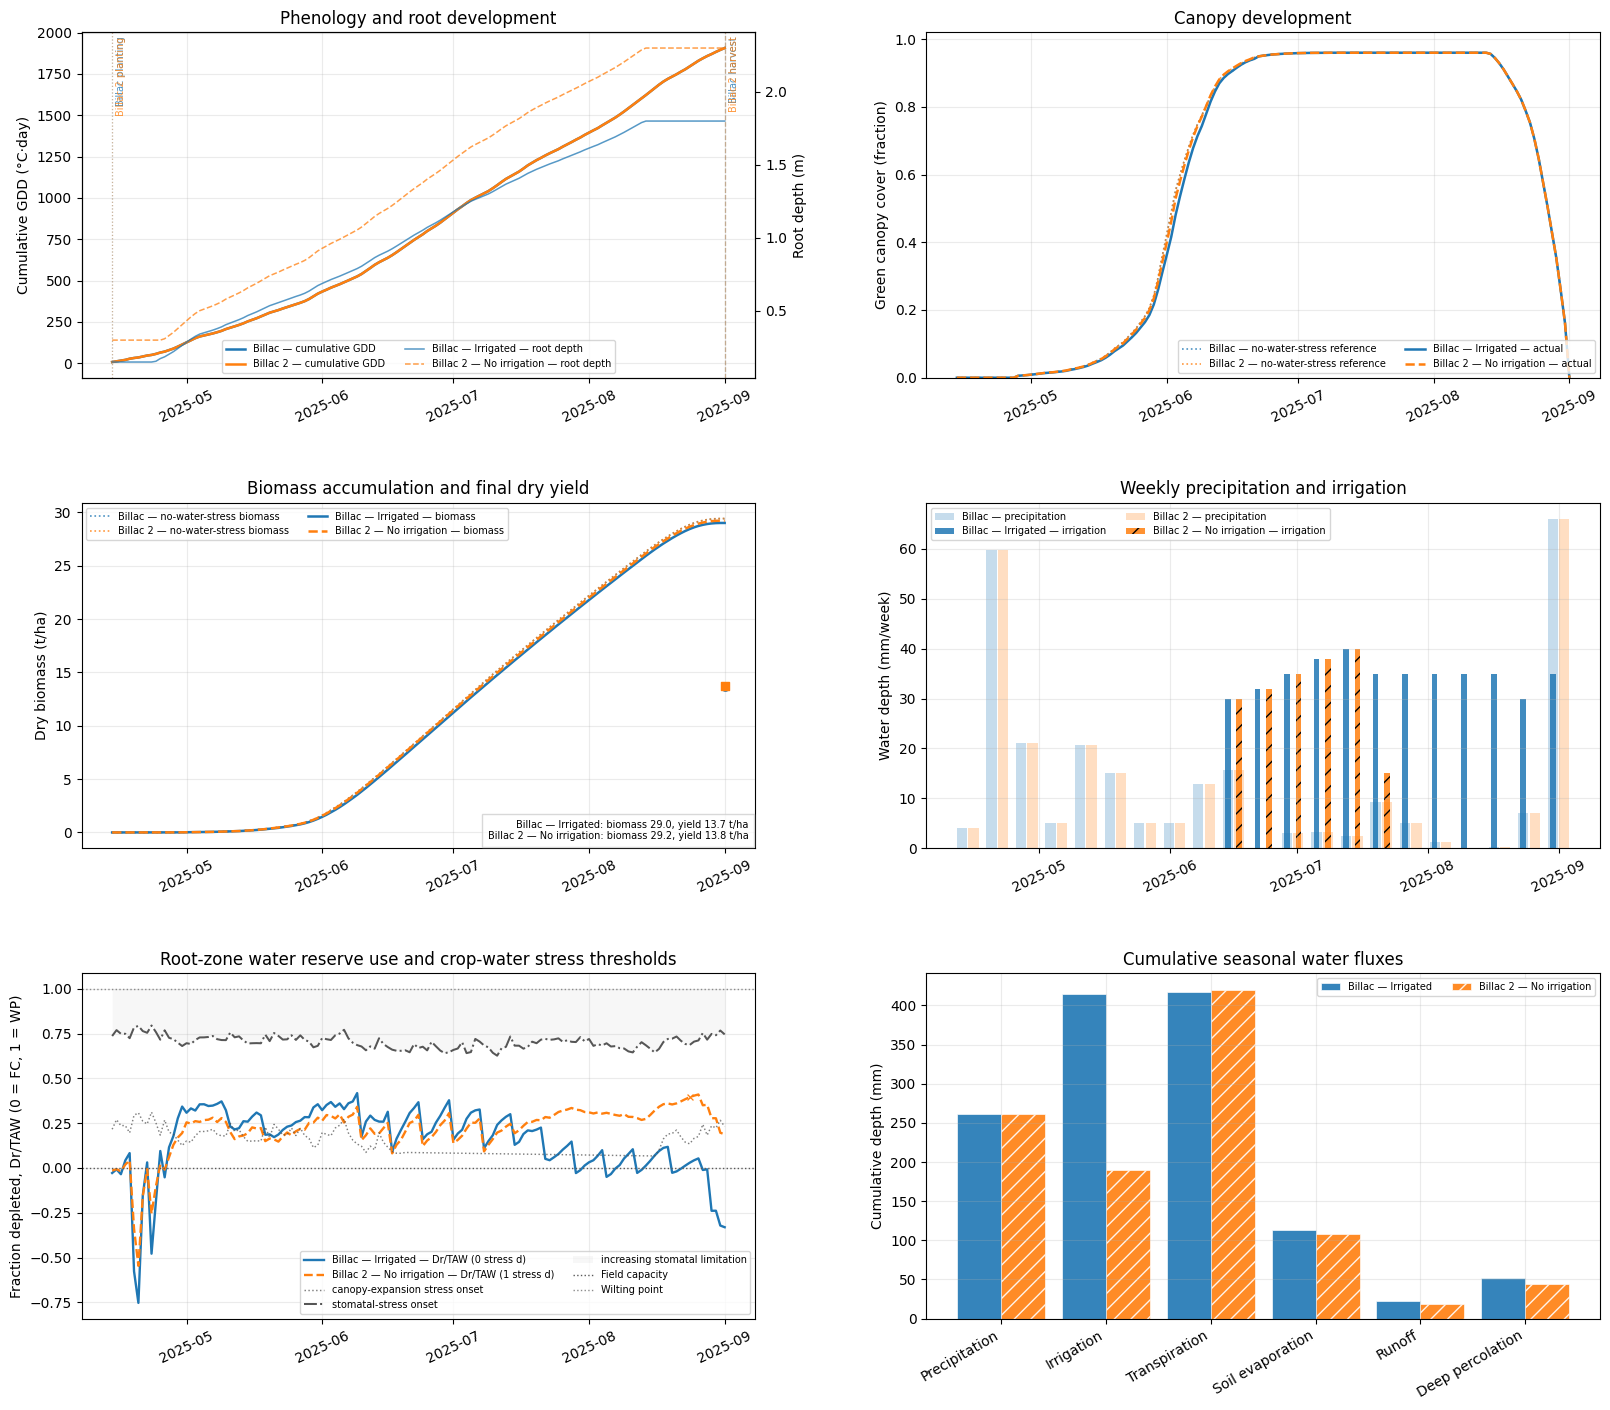

,parcel,scenario,final_dry_yield_t_ha,potential_dry_yield_t_ha,irrigation_mm,transpiration_mm,deep_percolation_mm,transpiration_stress_days,minimum_tr_over_trpot,maximum_root_zone_depletion_fraction
0,Billac,Irrigated,13.65,13.84,415.0,417.82,52.09,0,1.00,0.42
1,Billac 2,No irrigation,13.75,13.84,190.0,420.22,44.20,1,0.97,0.41


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

from irrigator.water_balance.plot_aquacrop_summary import (
    plot_aquacrop_season,
    summarize_aquacrop_seasons,
)
from irrigator.water_balance.aquacrop_adapter import soil_to_aquacrop

sim_start = "2025-01-01"

runs = {
    "Billac irrigated": {
        "parcel": "Billac",
        "scenario": "Irrigated",
        "crop_growth": hist_run.crop_growth,
        "water_flux": hist_run.water_flux,
        "daily_stress": hist_run.daily_stress,
        "soil": soil_to_aquacrop(soil).profile,
        "sim_start": sim_start,
        "season": 0,
    },
    "Billac optimized": {
            "parcel": "Billac 2",
            "scenario": "No irrigation",
            "crop_growth": hist_run2.crop_growth,
            "water_flux": hist_run2.water_flux,
            "daily_stress": hist_run2.daily_stress,
            "soil": soil_to_aquacrop(soil).profile,
            "sim_start": sim_start,
            "season": 0,
        },
}

fig, prepared = plot_aquacrop_season(
    runs,
    figsize=(16, 14),
)

# fig.savefig(
#     "aquacrop_2025_scenarios.png",
#     dpi=200,
#     bbox_inches="tight",
# )

plt.show()


series_metadata = {
    name: {
        "parcel": data.attrs["parcel"],
        "scenario": data.attrs["scenario"],
    }
    for name, data in prepared.items()
}

summary = summarize_aquacrop_seasons(
    prepared,
    series_metadata,
)

display(
    summary[
        [
            "parcel",
            "scenario",
            "final_dry_yield_t_ha",
            "potential_dry_yield_t_ha",
            "irrigation_mm",
            "transpiration_mm",
            "deep_percolation_mm",
            "transpiration_stress_days",
            "minimum_tr_over_trpot",
            "maximum_root_zone_depletion_fraction",
        ]
    ].round(2)
)


In [ ]:
summary[
        [
            "parcel",
            "scenario",
            "final_dry_yield_t_ha",
            "potential_dry_yield_t_ha",
            "irrigation_mm",
            "transpiration_mm",
            "deep_percolation_mm",
            "transpiration_stress_days",
            "minimum_tr_over_trpot",
            "maximum_root_zone_depletion_fraction",
        ]
    ].round(2).to_csv("/home/mbaldacchino/data/summary.csv")

In [11]:
hist_run.crop_growth

,time_step_counter,season_counter,dap,gdd,gdd_cum,z_root,canopy_cover,canopy_cover_ns,biomass,biomass_ns,harvest_index,harvest_index_adj,DryYield,FreshYield,YieldPot
0,0.0,-1.0,0.0,0.300000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1.0,-1.0,0.0,0.300000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2.0,-1.0,0.0,0.300000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,3.0,-1.0,0.0,0.300000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,4.0,-1.0,0.0,0.300000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,239.0,0.0,137.0,13.821592,1857.903434,1.8,0.429639,0.429639,2891.642302,2932.187504,0.431510,0.431808,12.486342,13.873713,12.652681
240,240.0,0.0,138.0,11.883970,1869.787404,1.8,0.354778,0.354778,2897.024107,2937.569310,0.441208,0.441513,12.790729,14.211921,12.960789
241,241.0,0.0,139.0,13.191099,1882.978503,1.8,0.260279,0.260279,2900.137267,2940.682470,0.450906,0.451217,13.085923,14.539915,13.259713
242,242.0,0.0,140.0,12.088560,1895.067063,1.8,0.161716,0.161716,2901.404700,2941.949903,0.460604,0.460922,13.373215,14.859128,13.550738


---
## Block 5a — Operational forecast with AquaCrop

With AquaCrop, forecasting means rerunning the full simulation from Jan 1
with different future forcings appended. This preserves the stress-growth
coupling — a crop that was stressed in June will have smaller canopy in
July, which reduces water demand.

- **AROME** (0-48h): one AquaCrop run with deterministic forecast appended
- **IFS ENS** (0-15d): 50 AquaCrop runs, one per ensemble member
- **Blended report**: AROME days 0-2 (high resolution), IFS ENS days 3+ (ensemble spread)

In [6]:
# --- Cell: Extract current state from historical AquaCrop run ---
# (put this right after Block 3-4)

from irrigator.water_balance.aquacrop_adapter import (
    aquacrop_to_current_state,
    build_blended_stress_report,
    run_ensemble_aquacrop,
)

current_state = aquacrop_to_current_state(hist_run, soil, LAST_ERA5_DAY)

print(f"Current state at {LAST_ERA5_DAY}:")
print(f"  Depletion:  {current_state.depletion:.0f} mm")
print(f"  TAW:        {current_state.taw:.0f} mm")
print(f"  RAW:        {current_state.raw:.0f} mm")
print(f"  Ks:         {current_state.stress_coeff:.3f}")
print(f"  Root depth: {current_state.z_root:.2f} m")
print(f"  GDD:        {current_state.gdd:.0f}")
print(f"  Stage:      {current_state.crop_stage}")


Current state at 2026-08-11:
  Depletion:  68 mm
  TAW:        271 mm
  RAW:        167 mm
  Ks:         1.000
  Root depth: 2.30 m
  GDD:        1776
  Stage:      harvest


/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:606: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],


In [7]:
# --- Cell: Build historical forcing for forecast branching ---

from irrigator.atmospheric.forcing import extract_parcel_forcing
from irrigator.forecasts.arome_processing import load_arome_daily_cache
from datetime import timedelta
import numpy as np

# ERA5-Land historical
era5_last = pd.Timestamp(era5_daily.valid_time.values[-1]).date()
era5_forcing = forcing.slice(SIMULATION_START, era5_last)

# AROME gap fill (era5_last → yesterday)
gap_start = era5_last + timedelta(days=1)
gap_end = TODAY - timedelta(days=1)

if gap_start <= gap_end:
    arome_gap = load_arome_daily_cache(gap_start, gap_end, mode="static")
    gap_forcing = extract_parcel_forcing(arome_gap, parcel, terrain)
    historical_forcing = era5_forcing.concat(gap_forcing)
    print(f"Gap filled: {gap_forcing.n_days} days ({gap_start} → {gap_end})")
else:
    historical_forcing = era5_forcing
    print("No gap to fill")

print(f"Historical forcing: {historical_forcing.n_days} days")



20:01:28 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 6 days from ERA5-Land at grid cell (0, 45)
20:01:28 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
20:01:28 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 6 days, T=[19.0, 38.6]°C, total precip=3 mm, mean Rs=23.0 MJ/m²/day


Gap filled: 6 days (2026-08-12 → 2026-08-17)
Historical forcing: 229 days


In [ ]:
# --- Cell: AROME 48h deterministic forecast ---

arome_today = load_arome_daily_cache(TODAY , TODAY + timedelta(days=1), mode="forecast")
arome_forcing_48h = extract_parcel_forcing(arome_today, parcel, terrain)
# Fix date alignment if needed
arome_forcing_48h.dates = arome_forcing_48h.dates #- np.timedelta64(1, "D")

print(f"AROME forecast: {arome_forcing_48h.n_days} days")
print(f"  T range: [{arome_forcing_48h.t_min.min():.1f}, {arome_forcing_48h.t_max.max():.1f}] °C")

# Run full AquaCrop: historical + AROME 48h
arome_full_forcing = historical_forcing.concat(arome_forcing_48h)


arome_run = run_aquacrop(
    forcing=arome_full_forcing,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    sim_end=pd.Timestamp(arome_full_forcing.dates[-1]).date(),
    initial_soil_water_profile=initial_soil_water_parcel
)

# Quick check: AROME Ks for the forecast days
arome_stress = arome_run.daily_stress
print(f"AROME last 3 days Ks: {arome_stress.ks.iloc[-4:-1].values}")


20:01:28 [arome] WARNING: 1 missing days: [datetime.date(2026, 8, 19)]
20:01:29 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 2 days from ERA5-Land at grid cell (0, 45)
20:01:29 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
20:01:29 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 2 days, T=[15.2, 30.8]°C, total precip=0 mm, mean Rs=22.7 MJ/m²/day
20:01:29 [irrigator.water_balance.aquacrop_adapter] WARNING: Extending AquaCrop numerical soil from observed 2.00m to 2.40m so roots with Zmax=2.30m have a safe terminal compartment; the deepest observed hydraulic layer is extrapolated below 2.00m.
20:01:29 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.40m depth, 24 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


AROME forecast: 2 days
  T range: [15.2, 30.8] °C
MaizeGDD


20:01:29 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2026-01-01 → 2026-08-19 (229 days), GDD=1893, CC=0.18, biomass=2693 kg/ha


AROME last 3 days Ks: [1. 1. 1.]


/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:606: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],


In [ ]:
# --- Cell: IFS ENS ensemble ---

from irrigator.ingestion.ifs_ens_client import load_ifs_daily

ifs_daily = load_ifs_daily(processed_dir=PROCESSED_DIR)

# Extract per-member forcing at parcel level
member_forcings = {}
for m in ifs_daily.number.values:
    member_ds = ifs_daily.sel(number=m)
    forcing_m = extract_parcel_forcing(member_ds, parcel, terrain)
    # Filter to remove arome overlap + limit due to shift utc + 1
    member_forcings[int(m)] = forcing_m.slice(start=TODAY + timedelta(2), end=TODAY + timedelta(14)) # hsould be 14

print(
    f"IFS ENS: {len(member_forcings)} members, {member_forcings[next(iter(member_forcings))].n_days} days"
)

# Run AquaCrop for each member (full simulation: Jan 1 → forecast end)
# Each member gets historical + its own forecast forcing
ensemble_stats = run_ensemble_aquacrop(
    historical_forcing=historical_forcing,
    arome_forcing=arome_forcing_48h,
    member_forcings=member_forcings,
    parcel=parcel,
    terrain=terrain,
    soil_profile=soil,
    sim_start=SIMULATION_START,
    today=TODAY - timedelta(days=1),
    initial_soil_water_profile=initial_soil_water_parcel,
)

print(f"Ensemble stats: {len(ensemble_stats)} days")
for s in ensemble_stats[:3]:
    print(
        f"  Day {s.day_offset}: Ks={s.ks_mean:.3f} (p25={s.ks_p25:.3f}, p75={s.ks_p75:.3f}), "
        f"stress={s.n_members_stressed}/{s.n_members_total}"
    )

# pd.Timestamp(arome_full_forcing.dates[-2]).date()

20:01:29 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
20:01:29 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
20:01:29 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[13.2, 28.8]°C, total precip=42 mm, mean Rs=16.5 MJ/m²/day
20:01:29 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
20:01:29 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
20:01:29 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[11.7, 28.3]°C, total precip=18 mm, mean Rs=13.9 MJ/m²/day
20:01:29 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 16 days from ERA5-Land at grid cell (0, 45)
20:01:29 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
20:01:29 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 16 days, T=[12.5, 29.6]°C,

IFS ENS: 50 members, 13 days
MaizeGDD


/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:606: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:606: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:606: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:606: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:606: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aqu

Ensemble stats: 13 days
  Day 0: Ks=1.000 (p25=1.000, p75=1.000), stress=0/50
  Day 1: Ks=1.000 (p25=1.000, p75=1.000), stress=0/50
  Day 2: Ks=1.000 (p25=1.000, p75=1.000), stress=0/50


In [9]:
# --- Cell: Blend AROME + IFS ENS into stress report ---

stress_report = build_blended_stress_report(
    arome_run=arome_run,
    ensemble_stats=ensemble_stats,
    today=TODAY,
    arome_days=2,
)

print(
    f"Blended report: {len(stress_report.daily_stats)} days "
    f"({stress_report.arome_days} AROME + {stress_report.ens_days} IFS ENS)"
)
for d in stress_report.daily_stats[:5]:
    print(
        f"  {d.date.date() if hasattr(d.date, 'date') else d.date}: "
        f"[{d.source}] Ks={d.ks_median:.3f}, stress_prob={d.stress_probability:.0%}"
    )


NameError: name 'arome_run' is not defined

NameError: name 'stress_report' is not defined

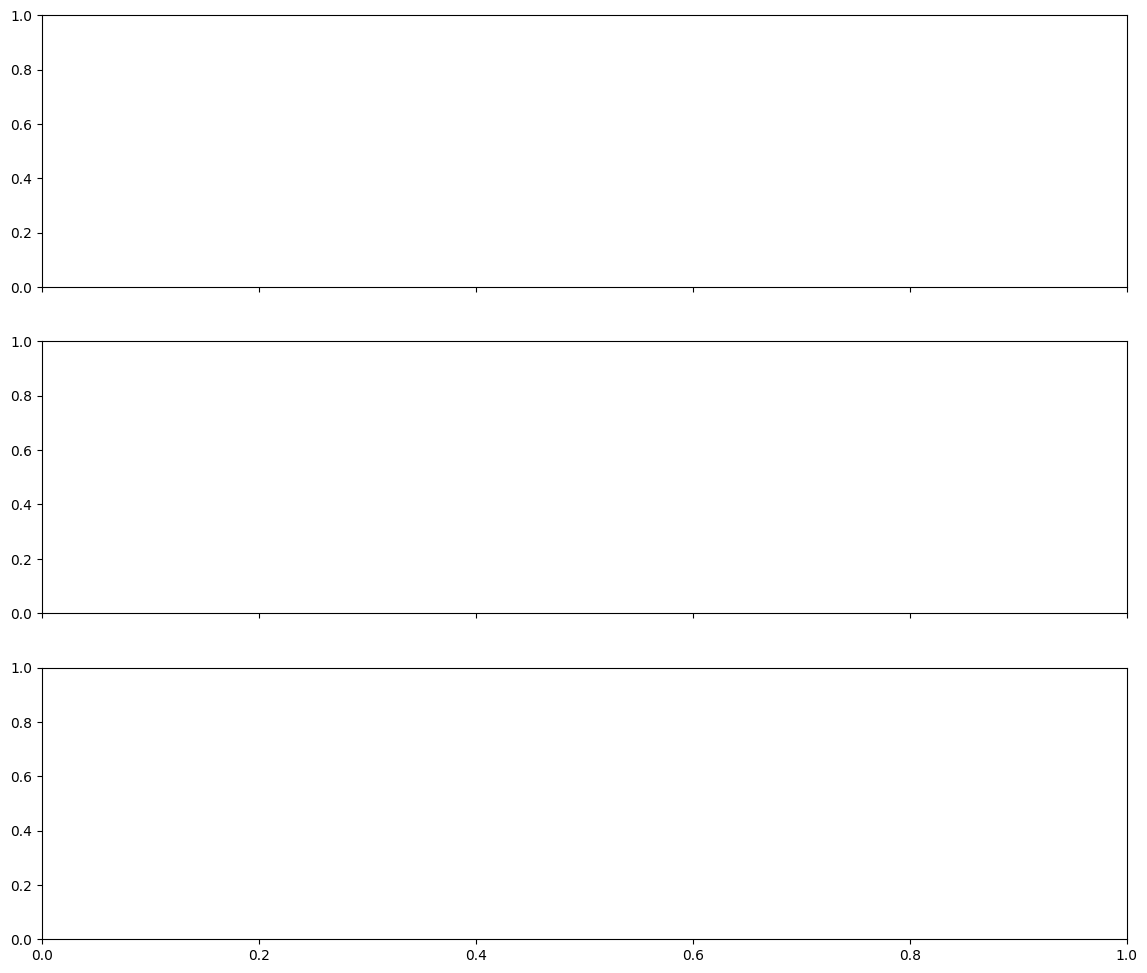

In [12]:
# --- Cell: Plot ensemble forecast (same as before, works unchanged) ---

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

dates = [d.date for d in stress_report.daily_stats]
sources = [d.source for d in stress_report.daily_stats]

# Ks with ensemble spread
ax = axes[0]
ks_med = [d.ks_median for d in stress_report.daily_stats]
ks_p25 = [d.ks_p25 for d in stress_report.daily_stats]
ks_p75 = [d.ks_p75 for d in stress_report.daily_stats]
ks_min = [d.ks_min for d in stress_report.daily_stats]
ks_max = [d.ks_max for d in stress_report.daily_stats]

ax.fill_between(dates, ks_min, ks_max, alpha=0.1, color="blue", label="min-max")
ax.fill_between(dates, ks_p25, ks_p75, alpha=0.7, color="blue", label="p25-p75")
ax.plot(dates, ks_med, "b-", lw=2, label="median")
ax.axhline(0.9, color="red", ls="--", alpha=0.5, label="Stress threshold")

for i, (d, src) in enumerate(zip(dates, sources)):
    if i == 0 or sources[i] != sources[i - 1]:
        ax.axvline(d, color="gray", ls=":", alpha=0.3)
        ax.text(d, 1.02, src, fontsize=8, rotation=45, transform=ax.get_xaxis_transform())

ax.set_ylabel("Ks (Tr/TrPot)")
ax.set_title("Crop stress — AquaCrop ensemble forecast")
ax.legend(loc="lower left")

# Stress probability
ax = axes[1]
stress_prob = [d.stress_probability for d in stress_report.daily_stats]
colors = ["red" if p > 0.7 else "orange" if p > 0.4 else "green" for p in stress_prob]
ax.bar(dates, [p * 100 for p in stress_prob], color=colors, alpha=0.7)
ax.axhline(70, color="red", ls="--", alpha=0.5, label=">70%: irrigate")
ax.axhline(40, color="orange", ls="--", alpha=0.5, label="40-70%: consider")
ax.set_ylabel("Stress probability (%)")
ax.set_title("Probability of crop stress (Ks < 0.9)")
ax.legend()

# Precipitation
ax = axes[2]
precip_mean = [d.precip_mean for d in stress_report.daily_stats]
ax.bar(dates, precip_mean, color="steelblue", alpha=0.7, label="mean precip")
ax.set_ylabel("mm/day")
ax.set_title("Forecast precipitation")
ax.legend()

plt.tight_layout()
plt.show()


---
## Block 5b — Seasonal Outlook (SEAS5, optional)

PCA analog matching → daily disaggregation → ensemble water balance.
Set `RUN_SEAS5 = True` at the top to enable.

In [10]:
seasonal_scenarios = None
member_forcings_to_harvest = None
import pandas as pd
RUN_SEAS5 = True
PLOT_SEAS5_PCA = True


if RUN_SEAS5:
    import xarray as xr
    from irrigator.ingestion.cds_client import (
        fetch_seas5,
        fetch_seas5_hindcasts,
        open_seas5,
    )
    from irrigator.forecasts.seas5_processor import (
        prepare_seas5_monthly,
        open_era5_daily_archive,
        build_era5_monthly_climatology,
        build_seas5_hindcast_climatology,
        correct_seas5_monthly,
    )
    from irrigator.forecasts.disaggregation import (
        MATCHING_VARIABLES,
        generate_seasonal_scenarios,
        project_seas5_members_to_pca,
        get_historical_monthly_fields,
        build_metropolitan_france_mask,
        build_intersection_mask,
        _coarsen_to_seas5,
        build_historical_pca,
    )
    from irrigator.forecasts.pca_framework import fit_monthly_regional_pca
    from irrigator.forecasts.pipeline import extend_ifs_members_with_seasonal

    init_year = TODAY.year
    init_month = TODAY.month
    analog_start_year = 1993
    analog_end_year = TODAY.year - 1

    

    # ------------------------------------------------------------------
    # 1) SEAS5 forecast + one-time hindcast climatology
    # ------------------------------------------------------------------
    # The new seasonal path uses tmin/tmean/tmax/dewpoint/wind/radiation/precip.
    # Set REFRESH_SEAS5=True once if the existing cached file contains only the
    # older temperature + precipitation request.
    fetch_seas5(
        year=init_year,
        month=init_month,
        raw_dir=RAW_DIR,
        overwrite=REFRESH_SEAS5,
    )
    print("Fetched")
    if FETCH_SEAS5_HINDCASTS:
        fetch_seas5_hindcasts(
            init_month=init_month,
            raw_dir=RAW_DIR,
            overwrite=REFRESH_SEAS5,
        )

    seas5_raw = open_seas5(raw_dir=RAW_DIR, year=init_year, month=init_month)
    
    # seas5_monthly = prepare_seas5_monthly( # TO FOCUS ON
    #     seas5_raw,
    #     init_year=init_year,
    #     init_month=init_month,
    # )
    seas5_monthly = seas5_raw

    # Historical ERA5-Land archive used for both climatology and analogs.
    # These annual daily files must already exist in data/processed/atmospheric.
    era5_monthly = _coarsen_to_seas5(get_historical_monthly_fields())
    era5_clim = build_era5_monthly_climatology(
        start_year=1993,
        end_year=2016,
        era5_monthly=era5_monthly,
    )

    seasonal_dir = PROCESSED_DIR / "seasonal"
    seasonal_dir.mkdir(parents=True, exist_ok=True)
    hindcast_clim_path = seasonal_dir / f"seas5_hindcast_clim_init_{init_month:02d}.nc"
    if hindcast_clim_path.exists() and not REFRESH_SEAS5:
        seas5_clim = xr.open_dataset(hindcast_clim_path)
    else:
        seas5_clim = build_seas5_hindcast_climatology(
            raw_dir=RAW_DIR,
            init_month=init_month,
            start_year=1993,
            end_year=2016,
        )
        seas5_clim.load().to_netcdf(hindcast_clim_path)

    seas5_corrected = correct_seas5_monthly(
        seas5_monthly,
        era5_climatology=era5_clim,
        init_month=init_month,
        seas5_climatology=seas5_clim,
    )

    # ------------------------------------------------------------------
    # 2) France-level PCA. Cache the monthly ERA5 fields: this avoids
    #    re-reading/aggregating decades of daily ERA5 at every daily run.
    # ------------------------------------------------------------------

    # france_pca = build_historical_pca(
    #     overwrite_era5=False,
    #     variables=MATCHING_VARIABLES,
    #     n_components=10,
    # )
    france_pca = build_historical_pca(
        overwrite_era5=False,
        variables=MATCHING_VARIABLES,
        target_grid=seas5_corrected,
        n_components=10,
    )
    print("PCA")

    # IFS is retained wherever it overlaps. The first seasonal month is
    # reconstructed as a full month before being sliced at the transition.
    seasonal_transition = TODAY + timedelta(days=15)
    seasonal_scenarios = generate_seasonal_scenarios(
        cfg=cfg,
        seas5_corrected=seas5_corrected,
        init_year=init_year,
        init_month=init_month,
        n_leads=3,
        variables=MATCHING_VARIABLES,
        method="sample",
        analog_top_k=1,
        random_seed=42,
        start_date=seasonal_transition,
        pca_model=france_pca,
        # Optional safeguard if you want to reject extreme precipitation
        # amplitude corrections, e.g. (0.25, 4.0). None preserves the target
        # monthly precipitation exactly for every selected analog.
        precip_scale_bounds=None,
    )

    expected_harvest = pd.Timestamp(parcel.crop["expected_harvest"]).date()
    member_forcings_to_harvest = extend_ifs_members_with_seasonal(
        member_forcings,
        seasonal_scenarios,
        parcel=parcel,
        terrain=terrain,
        known_prefix_forcing=historical_forcing.concat(arome_forcing_48h),
        end_date=expected_harvest,
    )

    print(f"SEAS5-conditioned scenarios: {len(seasonal_scenarios)}")
    print(f"PCA variables: {MATCHING_VARIABLES}")
    print(
        "Common member horizon:",
        min(pd.Timestamp(f.dates[-1]).date() for f in member_forcings_to_harvest.values()),
    )
    print("First member analogs:")
    for a in seasonal_scenarios[0].analogs:
        print(
            f"  target {a.target_year}-{a.target_month:02d} -> "
            f"ERA5 {a.analog_year}-{a.analog_month:02d} "
            f"(rank {a.rank}, d={a.distance:.2f})"
        )
else:
    print("SEAS5 seasonal scenarios skipped (set RUN_SEAS5=True to enable)")

    # ------------------------------------------------------------------
    # 4) PCA diagnostic: historical ERA5 months vs SEAS5 ensemble
    # ------------------------------------------------------------------
    if PLOT_SEAS5_PCA and seasonal_scenarios and france_pca.pc_scores.sizes["component"] >= 2:
        first_target = seasonal_scenarios[0].analogs[0]
        pca_plot_lead = (first_target.target_year - init_year) * 12 + (first_target.target_month - init_month) + 1
        seas5_pc = project_seas5_members_to_pca(
            seas5_corrected,
            france_pca,
            pca_variables,
            init_year=init_year,
            init_month=init_month,
            lead=pca_plot_lead,
        )
        hist_pc = france_pca.pc_scores.sel(
            time=france_pca.pc_scores.time.dt.month == first_target.target_month
        )

        fig, ax = plt.subplots(figsize=(9, 6))
        ax.scatter(
            hist_pc.sel(component="PC1"),
            hist_pc.sel(component="PC2"),
            alpha=0.65,
            label=f"ERA5-Land historical {first_target.target_month:02d}",
        )
        for ts, x, y in zip(
            pd.to_datetime(hist_pc.time.values),
            hist_pc.sel(component="PC1").values,
            hist_pc.sel(component="PC2").values,
        ):
            ax.annotate(str(ts.year), (x, y), xytext=(3, 3), textcoords="offset points", fontsize=7)
        ax.scatter(
            seas5_pc["PC1"],
            seas5_pc["PC2"],
            marker="x",
            s=45,
            label=f"Corrected SEAS5 {first_target.target_year}-{first_target.target_month:02d}",
        )
        ax.axhline(0, linewidth=0.6, alpha=0.4)
        ax.axvline(0, linewidth=0.6, alpha=0.4)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_title("France-level PCA: SEAS5 ensemble vs historical ERA5-Land months")
        ax.legend()
        fig.tight_layout()
        plt.show()


20:01:43 [irrigator.ingestion.cds_client] INFO: SEAS5 2026-08 already exists: data/raw/seas5/seas5_2026_08.nc


Fetched


20:01:46 [irrigator.forecasts.pca_framework] INFO: Pooled regional anomaly PCA: 163 monthly samples, 873/873 features, 10 PCs, 85.3% variance


PCA
2022
8
<xarray.Dataset> Size: 199MB
Dimensions:         (valid_time: 365, latitude: 106, longitude: 161)
Coordinates:
  * latitude        (latitude) float64 848B 51.5 51.4 51.3 ... 41.2 41.1 41.0
  * longitude       (longitude) float64 1kB -6.0 -5.9 -5.8 -5.7 ... 9.8 9.9 10.0
  * valid_time      (valid_time) datetime64[ns] 3kB 2022-01-01 ... 2022-12-31
    number          int64 8B ...
    expver          (valid_time) <U4 6kB ...
Data variables:
    t_min           (valid_time, latitude, longitude) float32 25MB ...
    t_max           (valid_time, latitude, longitude) float32 25MB ...
    t_mean          (valid_time, latitude, longitude) float32 25MB ...
    dewpoint        (valid_time, latitude, longitude) float32 25MB ...
    wind_speed_10m  (valid_time, latitude, longitude) float32 25MB ...
    pressure_kpa    (valid_time, latitude, longitude) float32 25MB ...
    rs_mj           (valid_time, latitude, longitude) float32 25MB ...
    precip_mm       (valid_time, latitude, longitu

20:02:32 [irrigator.forecasts.disaggregation] INFO: Generated 51 SEAS5-conditioned daily scenarios with 9 shared variables
20:02:32 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 61 days from ERA5-Land at grid cell (0, 45)
20:02:32 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
20:02:32 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 61 days, T=[7.6, 31.6]°C, total precip=281 mm, mean Rs=12.1 MJ/m²/day
20:02:32 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 61 days from ERA5-Land at grid cell (0, 45)
20:02:32 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
20:02:32 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 61 days, T=[6.6, 33.4]°C, total precip=146 mm, mean Rs=12.6 MJ/m²/day
20:02:32 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 61 days from ERA5-Land at grid cell (0, 45)
20:02:32 [irrigator.atmospheric.forcing] INFO: Lapse correcti

SEAS5-conditioned scenarios: 51
PCA variables: ['t2m', 't2m_min', 't2m_max', 'd2m', 'si10', 'ssrd', 'tp', 'e', 'msl']
Common member horizon: 2026-10-05
First member analogs:
  target 2026-08 -> ERA5 2022-08 (rank 1, d=15.49)
  target 2026-09 -> ERA5 2016-09 (rank 1, d=28.51)
  target 2026-10 -> ERA5 2019-10 (rank 1, d=23.96)


---
## Block 6 — Yield-constrained irrigation optimizer

This replaces the combinatorial stress-minimization search. Water stress is used only to
locate candidate intervention windows; the objective is **minimum irrigation subject to a
dry-yield constraint**. The optimizer first tests no future irrigation, adds only the events
needed to recover yield, then reduces each dose with a one-dimensional search.

For an operational run, each IFS member must be extended through harvest with the SEAS5
conditioned daily scenarios from Block 5b. A plan from yesterday can be passed through
`previous_plan`; dates inside the commitment horizon are preserved while their dose is updated.


In [ ]:
yield_plan = None
RUN_YIELD_OPTIMIZER = True

if RUN_YIELD_OPTIMIZER:
    if member_forcings_to_harvest is None:
        raise RuntimeError(
            "The yield optimizer needs weather through harvest. Set RUN_SEAS5=True "
            "and run Block 5b first."
        )

    from irrigator.water_balance.yield_optimizer import (
        YieldConstraint,
        optimize_operational_irrigation,
    )

    # Example: yesterday's plan. Keep [] on the first run. On subsequent days,
    # store yield_plan.recommended_events and pass that list here.
    previous_plan = []

    yield_plan = optimize_operational_irrigation(
        historical_forcing=historical_forcing,
        arome_forcing=arome_forcing_48h,
        future_member_forcings=member_forcings_to_harvest,
        parcel=parcel,
        terrain=terrain,
        soil_profile=soil,
        today=TODAY,
        sim_start=SIMULATION_START,
        previous_plan=previous_plan,
        commitment_days=2,
        constraint=YieldConstraint(
            max_relative_loss=0.01,  # accept <=1% dry-yield loss
            min_member_probability=0.80,  # in at least 80% of weather members
            absolute_tolerance_t_ha=0.01,
        ),
        stress_trigger_ks=0.98,  # date-finding signal only, NOT objective
        trigger_quantile=0.25,  # act before the earlier stressed members
        irrigation_lead_days=1,
        dose_resolution_mm=2.0,
        max_events=8,
        n_workers=10,
        require_harvest_horizon=True,
        initial_soil_water_profile=initial_soil_water_parcel
    )

    print(f"Feasible: {yield_plan.feasible}")
    print(f"Reason:   {yield_plan.reason}")
    print(f"Yield-constraint success probability: {yield_plan.success_probability:.0%}")
    print(f"Recommended water: {yield_plan.recommended_total_mm:.1f} mm")
    display(yield_plan.to_dataframe())

    ratios = yield_plan.optimized_evaluation.yield_ratios(yield_plan.reference_yields_t_ha)
    print(
        "Yield ratio vs attainable reference: "
        f"median={np.median(list(ratios.values())):.3f}, "
        f"min={np.min(list(ratios.values())):.3f}"
    )
else:
    print("Yield optimizer skipped (set RUN_YIELD_OPTIMIZER=True)")


NameError: name 'member_forcings_to_harvest' is not defined

### Branching equivalence test (recommended once after AquaCrop updates)

In [ ]:
if RUN_BRANCH_EQUIVALENCE_TEST:
    if member_forcings_to_harvest is None:
        raise RuntimeError("Run the SEAS5/harvest-horizon forecast block first.")

    from irrigator.water_balance.aquacrop_adapter import (
        AquaCropYieldBranchingEvaluator,
        IrrigationCandidate,
        _build_candidate_irrigation,
        run_aquacrop,
    )
    from irrigator.water_balance.yield_optimizer import _extract_dry_yield, _first_stress_date

    test_members = dict(list(sorted(member_forcings_to_harvest.items()))[:3])
    test_candidate = IrrigationCandidate(
        events=[(2, float(parcel.irrigation.get("max_dose_mm", 40.0)))],
        label="branch equivalence",
    )
    threshold = 0.98
    not_before = TODAY + timedelta(days=1)

    fast = AquaCropYieldBranchingEvaluator(
        historical_forcing=historical_forcing,
        arome_forcing=arome_forcing_48h,
        member_forcings=test_members,
        parcel=parcel,
        terrain=terrain,
        soil_profile=soil,
        sim_start=SIMULATION_START,
        today=TODAY,
        workers=1,
    )
    fast_rows = fast.evaluate(
        test_candidate,
        stress_threshold_ks=threshold,
        stress_not_before=not_before,
    )

    checks = []
    for member_id, member_future in test_members.items():
        full_forcing = historical_forcing.concat(arome_forcing_48h).concat(member_future)
        full_result = run_aquacrop(
            forcing=full_forcing,
            parcel=parcel,
            terrain=terrain,
            soil_profile=soil,
            sim_start=SIMULATION_START,
            sim_end=pd.Timestamp(member_future.dates[-1]).date(),
            irrigation_management=_build_candidate_irrigation(parcel, test_candidate, TODAY),
        )
        full_yield = _extract_dry_yield(full_result)
        full_stress = _first_stress_date(
            full_result,
            threshold_ks=threshold,
            not_before=not_before,
        )
        branch = fast_rows[int(member_id)]
        checks.append(
            {
                "member": int(member_id),
                "full_yield_t_ha": full_yield,
                "branch_yield_t_ha": branch.dry_yield_t_ha,
                "yield_abs_error": abs(full_yield - branch.dry_yield_t_ha),
                "full_first_stress": full_stress,
                "branch_first_stress": branch.first_stress_date,
                "stress_date_match": full_stress == branch.first_stress_date,
            }
        )

    branch_check = pd.DataFrame(checks)
    display(branch_check)
    assert branch_check["yield_abs_error"].max() < 1e-6, branch_check
    assert branch_check["stress_date_match"].all(), branch_check
    print("Branching equivalence passed on the sampled members.")
else:
    print("Branching equivalence test skipped")


In [ ]:
# --- Yield optimizer diagnostics ---
if yield_plan is not None:
    import matplotlib.pyplot as plt

    members = sorted(yield_plan.reference_yields_t_ha)
    ref = np.array([yield_plan.reference_yields_t_ha[m] for m in members])
    no_irr = np.array([yield_plan.no_irrigation_evaluation.member_yield_t_ha[m] for m in members])
    optimized = np.array([yield_plan.optimized_evaluation.member_yield_t_ha[m] for m in members])

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.scatter(members, ref, s=18, label="Max-feasible reference")
    ax.scatter(members, no_irr, s=18, label="No future irrigation")
    ax.scatter(members, optimized, s=18, label="Optimized plan")
    ax.set_xlabel("Weather ensemble member")
    ax.set_ylabel("Final dry yield (t/ha)")
    ax.set_title("Yield-constrained irrigation optimization")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    plt.show()


---
## Block 6c — Retrospective irrigation optimization

For a completed season, recorded irrigation **dates stay fixed** and only their doses are
allowed to change; a zero dose means the event could have been omitted. The reference is the
final dry yield produced by the farmer's recorded schedule under the same observed weather.
The search therefore answers: *how much water could have been removed without materially
changing harvest yield?*

In [18]:
# %%capture

historical_yield_optimization = None
RUN_HISTORICAL_OPTIMIZER = True

if RUN_HISTORICAL_OPTIMIZER:
    import xarray as xr
    from irrigator.config import load_parcel_config
    from irrigator.static_layers.soil import get_soil_profile
    from irrigator.static_layers.terrain import get_terrain_params, get_era5_elevation
    from irrigator.atmospheric.forcing import extract_parcel_forcing
    from irrigator.water_balance.yield_optimizer import (
        YieldConstraint,
        optimize_historical_irrigation_amounts,
    )

    parcel_hist = load_parcel_config(HISTORICAL_PARCEL_CONFIG)
    hist_year = pd.Timestamp(parcel_hist.crop["planting_date"]).year
    hist_start = date(hist_year, 1, 1)
    hist_end = pd.Timestamp(parcel_hist.crop["expected_harvest"]).date()

    terrain_hist = get_terrain_params(cfg, parcel_hist)
    terrain_hist.era5_elevation_m = get_era5_elevation(cfg, parcel_hist)
    soil_hist = get_soil_profile(cfg, parcel_hist)

    era5_hist = xr.open_dataset(PROCESSED_DIR / "atmospheric" / f"era5_daily_{hist_year}.nc")
    forcing_hist = extract_parcel_forcing(era5_hist, parcel_hist, terrain_hist).slice(
        hist_start, hist_end
    )
    from irrigator.water_balance.soil_water_content import (
        build_initial_soil_water_profile_from_era5_land,
    )

    historical_initial_soil_water_parcel = build_initial_soil_water_profile_from_era5_land(
        soil_profile=soil_hist,
        parcel_profile=parcel_hist,
        date=hist_start,
        processed_dir=PROCESSED_DIR,
        raw_dir=RAW_DIR,
        static_dir=STATIC_DIR,
    )


    historical_yield_optimization = optimize_historical_irrigation_amounts(
        observed_forcing=forcing_hist,
        parcel=parcel_hist,
        terrain=terrain_hist,
        soil_profile=soil_hist,
        sim_start=hist_start,
        sim_end=hist_end,
        constraint=YieldConstraint(
            max_relative_loss=0.005,  # <=0.5% vs the recorded schedule
            min_member_probability=1.0,  # deterministic historical weather
            absolute_tolerance_t_ha=0.01,
        ),
        dose_resolution_mm=1.0,
        max_passes=3,
        initial_soil_water_profile=historical_initial_soil_water_parcel,
    )

    print(f"Recorded irrigation:  {historical_yield_optimization.original_mm:.1f} mm")
    print(f"Optimized irrigation: {historical_yield_optimization.optimized_mm:.1f} mm")
    print(
        f"Potential saving:      {historical_yield_optimization.saved_mm:.1f} mm "
        f"({historical_yield_optimization.saved_fraction:.1%})"
    )
    display(historical_yield_optimization.to_dataframe())
else:
    print("Historical optimizer skipped (set RUN_HISTORICAL_OPTIMIZER=True)")


14:59:28 [irrigator.static_layers.terrain] INFO: Parcel billac_001 terrain: elev=140 m, slope=3.1°, aspect=89°
14:59:28 [irrigator.ingestion.cds_client] INFO: Opening 200 ERA5-Land files with dask


14:59:38 [irrigator.static_layers.soil] INFO: Parcel billac_001: using EU-SoilHydroGrids — AWC=235 mm, FC=[0.362, 0.342, 0.340, 0.337, 0.320, 0.319]
14:59:39 [irrigator.atmospheric.forcing] INFO: Parcel billac_001: extracted 365 days from ERA5-Land at grid cell (0, 45)
14:59:39 [irrigator.atmospheric.forcing] INFO: Lapse correction: Δz=-5 m, ΔT=0.03°C
14:59:39 [irrigator.atmospheric.forcing] INFO: Parcel billac_001 forcing: 365 days, T=[-4.0, 39.0]°C, total precip=nan mm, mean Rs=nan MJ/m²/day
14:59:39 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


MaizeGDD


14:59:39 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2025-01-01 → 2025-10-05 (244 days), GDD=1895, CC=0.16, biomass=2510 kg/ha
/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:737: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],
14:59:39 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop soil: 2.00m depth, 20 x 0.10m compartments, FC range 0.319-0.352, WP range 0.179-0.216, Ksat range 1-581 mm/day


MaizeGDD


...

MaizeGDD


15:00:03 [irrigator.water_balance.aquacrop_adapter] INFO: AquaCrop run: 2025-01-01 → 2025-10-05 (244 days), GDD=1895, CC=0.16, biomass=2496 kg/ha


Recorded irrigation:  415.0 mm
Optimized irrigation: 302.0 mm
Potential saving:      113.0 mm (27.2%)


/home/mbaldacchino/code/IrriGator/src/irrigator/water_balance/aquacrop_adapter.py:737: RuntimeWarning: invalid value encountered in divide
  wf["Tr"].values[:n] / wf["TrPot"].values[:n],


,date,recorded_mm,optimized_mm,saved_mm,removed
0,2025-06-10,30.0,30.0,0.0,False
1,2025-06-17,32.0,32.0,0.0,False
2,2025-06-24,35.0,35.0,0.0,False
3,2025-07-01,38.0,38.0,0.0,False
4,2025-07-08,40.0,40.0,0.0,False
5,2025-07-15,35.0,35.0,0.0,False
6,2025-07-22,35.0,23.0,12.0,False
7,2025-07-29,35.0,26.0,9.0,False
8,2025-08-05,35.0,28.0,7.0,False
9,2025-08-12,35.0,15.0,20.0,False


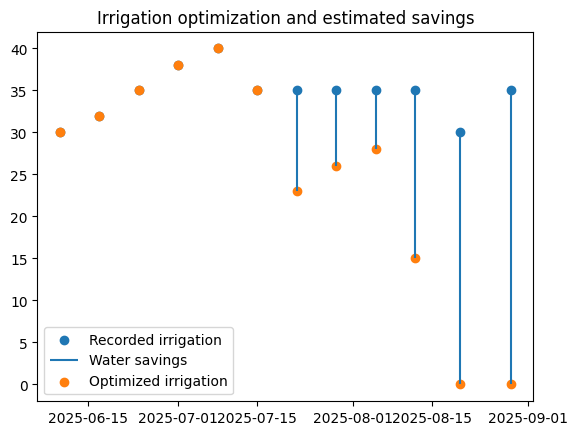

In [19]:
optimization = historical_yield_optimization.to_dataframe()
import matplotlib.pyplot as plt

plt.scatter(optimization["date"], optimization["recorded_mm"], label="Recorded irrigation")
plt.vlines(optimization["date"], ymax=optimization["recorded_mm"], ymin=optimization["optimized_mm"], label="Water savings")
plt.scatter(optimization["date"], optimization["optimized_mm"], label="Optimized irrigation")
plt.legend()
plt.title("Irrigation optimization and estimated savings")
plt.show()


In [17]:
historical_yield_optimization

HistoricalOptimizationResult(original_events=[(datetime.date(2025, 6, 10), 30.0), (datetime.date(2025, 6, 17), 32.0), (datetime.date(2025, 6, 24), 35.0), (datetime.date(2025, 7, 1), 38.0), (datetime.date(2025, 7, 8), 40.0), (datetime.date(2025, 7, 15), 35.0), (datetime.date(2025, 7, 22), 35.0), (datetime.date(2025, 7, 29), 35.0), (datetime.date(2025, 8, 5), 35.0), (datetime.date(2025, 8, 12), 35.0), (datetime.date(2025, 8, 20), 30.0), (datetime.date(2025, 8, 29), 35.0)], optimized_events=[(datetime.date(2025, 6, 10), 30.0), (datetime.date(2025, 6, 17), 32.0), (datetime.date(2025, 6, 24), 35.0), (datetime.date(2025, 7, 1), 38.0), (datetime.date(2025, 7, 8), 40.0), (datetime.date(2025, 7, 15), np.float64(25.0)), (datetime.date(2025, 7, 22), np.float64(15.0))], reference_yields_t_ha={0: 13.654788173854197}, optimized_evaluation=YieldScheduleEvaluation(candidate=IrrigationCandidate(events=[(160, 30.0), (167, 32.0), (174, 35.0), (181, 38.0), (188, 40.0), (195, 25.0), (202, 15.0)], label='hi

---
## Summary: data flow

```
ERA5-Land France-wide cache ──[Block 2: extract + downscale]──→ DailyForcing (parcel)
                                                                       │
                                                      [Blocks 3+4: simulation]──→ current_state
                                                                                        │
AROME France-wide cache ──[extract + downscale]──→ DailyForcing (parcel)                │
                                                         │                              │
IFS ENS download ──[process daily]──[extract]──→ 51× DailyForcing (parcel)              │
                                                         │                              │
                                              [Block 5a: ensemble forward balance]──────┤
                                                                                        │
SEAS5 ──[bias correct]──[PCA analog]──[extract]──→ N× DailyForcing                     │
                                                         │                              │
                                              [Block 5b: seasonal water balance]────────┤
                                                                                        │
                                              [Block 6: decision rules]─────→ IrrigationAdvice
```

All gridded data sources (ERA5-Land, AROME, IFS ENS, SEAS5 analogs) are France-wide.
Parcel extraction happens once through `extract_parcel_forcing()` — one function,
one set of corrections (lapse rate, radiation, wind), for all sources.